# Plotting Stuff

In [1]:
import numpy as np
X = np.linspace(0, 10, 40)
print(X)

[ 0.          0.25641026  0.51282051  0.76923077  1.02564103  1.28205128
  1.53846154  1.79487179  2.05128205  2.30769231  2.56410256  2.82051282
  3.07692308  3.33333333  3.58974359  3.84615385  4.1025641   4.35897436
  4.61538462  4.87179487  5.12820513  5.38461538  5.64102564  5.8974359
  6.15384615  6.41025641  6.66666667  6.92307692  7.17948718  7.43589744
  7.69230769  7.94871795  8.20512821  8.46153846  8.71794872  8.97435897
  9.23076923  9.48717949  9.74358974 10.        ]


In [2]:
type(X)

numpy.ndarray

In [3]:
C = np.cos(X)  # applies function to the vector, heavily optimized
print(C)

[ 1.          0.9673066   0.87136413  0.71844595  0.51855089  0.28474945
  0.03232915 -0.22220504 -0.46220996 -0.67199245 -0.8378355  -0.94889519
 -0.99790965 -0.981674   -0.90124984 -0.76189584 -0.57272391 -0.3461034
 -0.0968523   0.15873166  0.40393667  0.62272955  0.80080415  0.92651672
  0.99164735  0.99193733  0.9273677   0.80216048  0.62450255  0.40601041
  0.16097054 -0.09459467 -0.34397464 -0.57086321 -0.76042487 -0.90026478
 -0.98123926 -0.99805366 -0.94960852 -0.83907153]


In [4]:
import matplotlib.pyplot as plt

In [5]:
# only needed in jupyter notebook to show output plots inside book cell.
%matplotlib inline

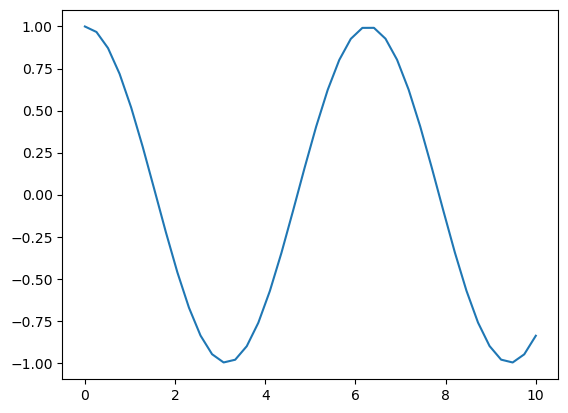

In [6]:
_ = plt.plot(X, C)    # Notice the underscore
plt.show()

In [7]:
S = np.sin(X)
print(S)

[ 0.          0.25360981  0.49063689  0.69558279  0.85504677  0.95860198
  0.99947728  0.97499996  0.88677052  0.740558    0.54592277  0.31559139
  0.06462451 -0.19056796 -0.43329981 -0.64769957 -0.81974833 -0.93819637
 -0.99529876 -0.98732176 -0.91478695 -0.78243716 -0.59892631 -0.37625358
 -0.12897884  0.12672941  0.37415123  0.5971085   0.78102277  0.91386845
  0.98695921  0.99551587  0.93897894  0.82104518  0.64942592  0.43534277
  0.19279396 -0.06236104 -0.31343844 -0.54402111]


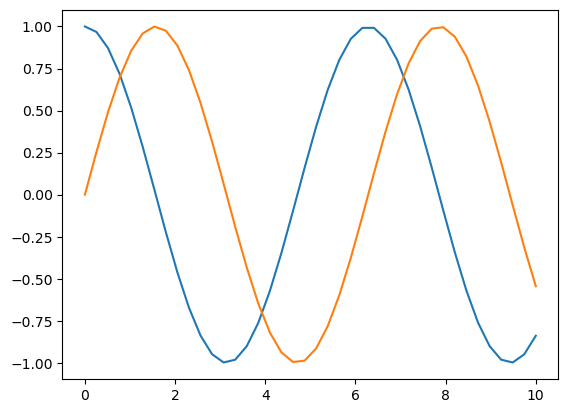

In [8]:
plt.figure()
plt.plot(X, C)
plt.plot(X, S)
plt.show()

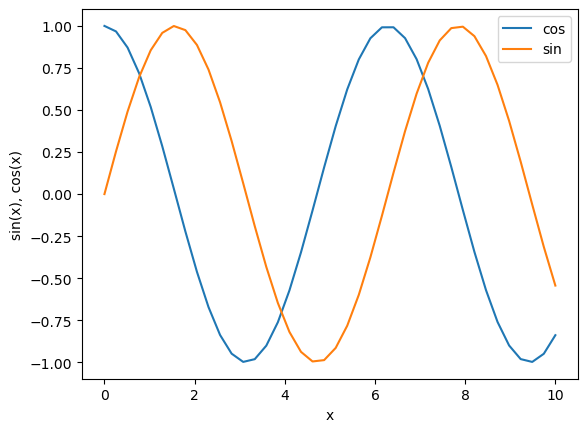

In [9]:
plt.figure()
plt.plot(X, C, label='cos')
plt.plot(X, S, label='sin')
plt.xlabel('x')
plt.ylabel('sin(x), cos(x)')
plt.legend()
plt.show()

# Case study: Time taken by fib(n)

In [10]:
def fibslow(n): # our old fib function
    if n <= 1:
        return n
    else:
        return fibslow(n-1) + fibslow(n - 2)

def fibfast(n): # DP approach of finding fib
    if n <= 1: return n

    a, b = 0, 1

    for i in range(1, n+1):
        a, b = b, a+b

    return a

In [11]:
def time_function(fn, X):   # fn is fucntion to be performed and X is range
    from datetime import datetime

    times = []
    for i in X:
        start_time = datetime.now()

        _ = fn(i)   # actuall call to the function, don't care about value

        end_time = datetime.now()
        time_taken = end_time - start_time  # returns a timedelta
        time_taken = time_taken.microseconds

        times.append(time_taken)

    return times

In [12]:
X = range(1, 30)

fibslow_times = time_function(fibslow, X)
fibfast_times = time_function(fibfast, X)

print(f"Slow: {fibslow_times}")
print(f"Fast: {fibfast_times}")

Slow: [15, 4, 4, 3, 3, 4, 6, 7, 11, 17, 26, 40, 64, 103, 182, 285, 467, 726, 1129, 2157, 2725, 5350, 12511, 11385, 17416, 28890, 42405, 78844, 112698]
Fast: [4, 6, 5, 2, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3]


In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

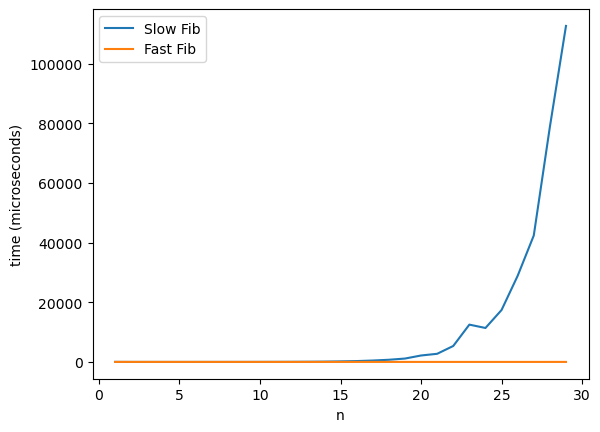

In [14]:
plt.figure()
plt.plot(X, fibslow_times, label= 'Slow Fib')
plt.plot(X, fibfast_times, label= 'Fast Fib')
plt.xlabel('n')
plt.ylabel('time (microseconds)')
plt.legend()
plt.show()